<a href="https://colab.research.google.com/github/haji8-de/AIFFEL_quest_rs/blob/main/MainQuest/Quest01/LLM-chatgpt1-encoderonly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
!pip install sentencepiece

In [149]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np # Used for demonstration of merging data if needed

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [150]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        # 학습 가능한 임베딩 레이어 사용
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(p=dropout)

        def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
          seq_len = x.size(1)

          # 위치 인덱스 생성: [0, 1, 2, ..., seq_len-1]
          pos_ids = torch.arange(seq_len, dtype=torch.long, device=x.device)

          # (seq_len) -> (1, seq_len) -> (1, seq_len, d_model) Broadcasting
          pos_ids = pos_ids.unsqueeze(0)

          # 입력에 위치 임베딩 더하기
          x = x + self.pos_embedding(pos_ids)
          return self.dropout(x)

In [151]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [152]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [153]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [154]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [155]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [156]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [157]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [158]:
class DecoderLayer(nn.Module):
    # For a decoder-only model, the padding_mask argument (meant for encoder-decoder attention)
    # is not directly used in the self-attention layer. Removing it from signature
    # to prevent potential confusion or misuse.
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)


        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    # Only look_ahead_mask is relevant for self-attention in a decoder-only layer
    def forward(self, x, look_ahead_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out1 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [159]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = LearnablePositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    # In a decoder-only model, padding_mask (for encoder-decoder attention) is not needed
    def forward(self, x, look_ahead_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            # Only pass look_ahead_mask for self-attention
            x = layer(x, look_ahead_mask=look_ahead_mask)

        return x

In [160]:
# import os
# import urllib
# # 코넬 대사 데이터셋 다운로드 URL
# url = 'http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip'
# zip_filename = 'cornell_movie_dialogs.zip'

# # 이미 파일이 없는 경우에만 다운로드
# if not os.path.exists(zip_filename):
#     print(f"Downloading {zip_filename} ...")
#     urllib.request.urlretrieve(url, zip_filename)
#     print("Download complete.")

# # ZIP 파일 압축 해제
# with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
#     zip_ref.extractall()  # 현재 디렉토리에 풀림

# # 코넬 대사 데이터 폴더 경로
# path_to_dataset = os.path.join(os.getenv('HOME'), "cornell movie-dialogs corpus")

# # 개별 파일 경로 설정
# path_to_movie_lines = os.path.join(path_to_dataset, 'movie_lines.txt')
# path_to_movie_conversations = os.path.join(path_to_dataset, 'movie_conversations.txt')

# print("path_to_dataset:", path_to_dataset)
# print("path_to_movie_lines:", path_to_movie_lines)
# print("path_to_movie_conversations:", path_to_movie_conversations)

In [161]:
import os
url = 'https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv'
filename = 'ChatbotData.csv'

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(os.path.join(os.getenv('HOME'), filename)):
    print(f"Downloading {filename} ...")
    urllib.request.urlretrieve(url, os.path.join(os.getenv('HOME'), filename))
    print("Download complete.")


path_to_conversations = os.path.join(os.getenv('HOME'), filename)

print("path_to_conversations:", path_to_conversations)

path_to_conversations: /root/ChatbotData.csv


In [162]:
data = pd.read_csv(path_to_conversations, names=['query', 'answer', 'label'], header=1)
#

In [163]:
data.head()

,query,answer,label
0,1지망 학교 떨어졌어,위로해 드립니다.,0
1,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
2,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
3,PPL 심하네,눈살이 찌푸려지죠.,0
4,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,0


In [164]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = 50000
print(MAX_SAMPLES)

50000


Total Data Size: 11822
Data Size: 11661
문장의 최단 길이: 1
문장의 최장 길이: 56
문장의 평균 길이: 12


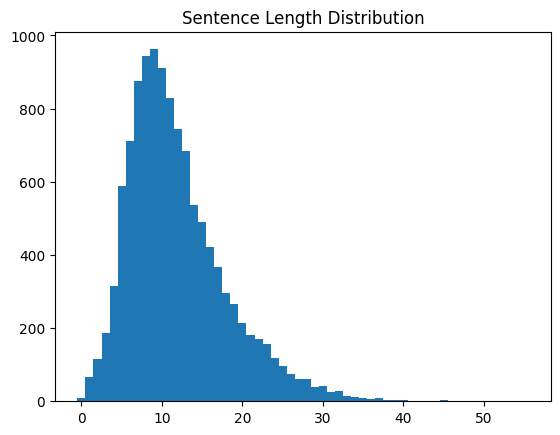

In [165]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(data['query']))  # set를 사용해서 중복을 제거합니다.

print("Total Data Size:", len(list(data['query'])))
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [166]:
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Z?.!,ㄱ-ㅎ가-힣0-9]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

슝=3


In [167]:
sample_sentence = "안녕하세요? Hello! I'm a student😊, nice to meet you!"

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

안녕하세요 ? hello ! i m a student , nice to meet you !


In [168]:
def read_cornell_data(data, max_samples=50000):
  pairs = []

  for ori_data in data:
    pairs.append(ori_data['query'], ori_data['answer'])

  print(pairs)
      # # 연속된 두 문장씩 (질문, 답변) 구성
      # for i in range(len(conv_list) - 1):
      #     q_id = conv_list[i]
      #     a_id = conv_list[i+1]
      #     q_text = id2line.get(q_id, "")
      #     a_text = id2line.get(a_id, "")
      #     # 간단 전처리(소문자 변환 정도만 예시)
      #     q_text = preprocess_sentence(q_text)
      #     a_text = preprocess_sentence(a_text)

      #     pairs.append((q_text, a_text))
      #     if len(pairs) >= max_samples:
      #         return pairs
  return pairs

In [169]:
class CornellDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2
            pad_id = sp.pad_id() if sp.pad_id() >= 0 else 0

            # GPT 입력 포맷: [BOS] + 질문 + [EOS] + 답변 + [EOS]
            # 이렇게 하나로 합쳐서 모델이 전체 맥락을 학습하게 합니다.
            full_ids = [bos_id] + q_ids + [eos_id] + a_ids + [eos_id]
# 길이 제한 (max_length보다 길면 자름)
            if len(full_ids) > max_length:
                full_ids = full_ids[:max_length]

            # 패딩 채우기 (길이 맞추기)
            pad_len = max_length - len(full_ids)
            full_ids = full_ids + [pad_id] * pad_len

            # 텐서로 변환하여 저장
            self.data.append(torch.tensor(full_ids, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 이제 __getitem__은 3개가 아닌 1개의 텐서만 반환합니다.
        return self.data[idx]

In [170]:
# corpus_file = os.path.join(os.getenv('HOME'), "clean_corpus.txt")
# pairs = read_cornell_data(data) # This line caused the error

# Fix: Directly extract queries and answers and preprocess them
fixed_pairs = []
# MAX_SAMPLES is already defined in cell q5YJ4R54e63S
pre_q_text = ""
pre_a_text = ""
for index, row in data.iterrows():
    if pre_q_text != "":
        fixed_pairs.append((pre_a_text, q_text))
    q_text = preprocess_sentence(row['query'])
    a_text = preprocess_sentence(row['answer'])
    fixed_pairs.append((q_text, a_text))
    pre_q_text = q_text
    pre_a_text = a_text

pairs = fixed_pairs # Assign the correctly generated pairs to 'pairs'

print(f"총 {len(pairs)}개의 질문-답변 쌍을 생성했습니다.")

총 23643개의 질문-답변 쌍을 생성했습니다.


In [171]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [172]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_cornell",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)


In [173]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_cornell.model")

True

In [174]:
dataset = CornellDataset(pairs, sp, max_length=40)

In [175]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

ValueError: too many values to unpack (expected 3)

In [ ]:
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

In [ ]:
# 예제 문장
sentence = "3박 4일 여행 하고 싶어"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


In [ ]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()


        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # In a decoder-only model, the padding mask for encoder input is not directly used
        # for the decoder's self-attention or cross-attention since there's no encoder.
        # Removing the creation and passing of this mask.
        # dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            # enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask
            # padding_mask=dec_padding_mask # No longer passed in decoder-only model
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [ ]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

In [ ]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [ ]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [ ]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(),lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [ ]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()# 배치에서 데이터를 꺼냄 (dataset 수정 반영)
    data = batch.to(device) # (batch_size, seq_len)

    # 입력: 마지막 토큰 제외 (0 ~ n-1)
    input_ids = data[:, :-1]

    # 정답: 첫번째 토큰 제외 (1 ~ n) -> 다음 단어 예측
    targets = data[:, 1:]

    optimizer.zero_grad()

    # 모델 예측
    logits = model(input_ids)  # (batch_size, seq_len-1, vocab_size)

    # Loss 계산
    # 차원 변경: (batch_size, vocab_size, seq_len-1) vs (batch_size, seq_len-1)
    loss = loss_function(logits.permute(0, 2, 1), targets)

    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, targets, pad_id=sp.pad_id())

In [ ]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)

            total_loss += loss.item() if hasattr(loss, 'item') else loss
            total_acc += acc.item() if hasattr(acc, 'item') else acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()
        # 에폭별 평균 계산

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        # 히스토리에 현재 에폭의 평균 값 저장
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
        # 3. 저장된 기록 반환
    return loss_history, acc_history

In [ ]:
%%time


train_loss, train_acc = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,  # 원하는 에폭 수
    device=device
)

In [ ]:
def plot_metrics(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_history, 'b-', label='Training Loss')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_history, 'r-', label='Training Accuracy')
    plt.title('Training Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_metrics(train_loss, train_acc)


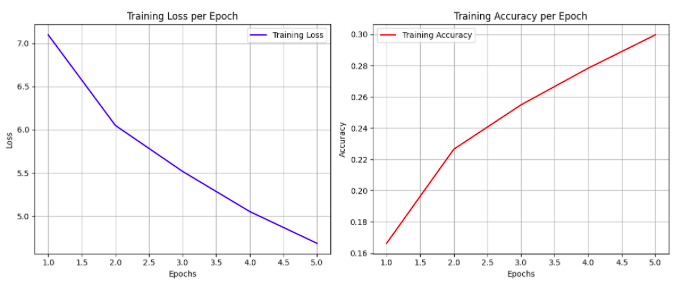

## 1차 실험
* 한국어 데이터
* 기본 에폭 5 : 증가하는 그래프(에폭 증가가능)
* 인코더 소스 제거
* lr=1.0적용
*

한번 쓰고 날라가서.....

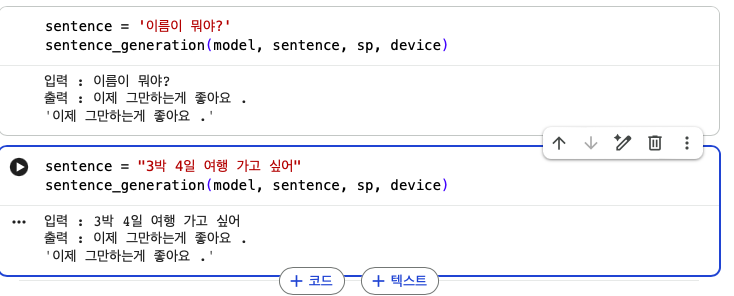

## 2차 실험
테스트를 포함한 실험 진행
* 똑같은 답변이 반복됨.
확인시 ;이제 그만하는게 좋아요; 라는 대답은 리스트에 존재하지 않음


In [ ]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [ ]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    # print("출력 :", predicted_sentence)
    return predicted_sentence

In [ ]:
sentence = "이름이 뭐야"
sentence_generation(model, sentence, sp, device)

In [ ]:
sentence = "3박 4일 여행 하고 싶어"
sentence_generation(model, sentence, sp, device)

In [ ]:
import pandas as pd

# 가정: df라는 데이터프레임이 있고, 정답 컬럼 이름이 'target'이라고 할 때
# df = pd.read_csv('train_data.csv')

# 상위 5개 값의 비율 확인0
top_5_stats = data['answer'].value_counts(normalize=True).head(10) * 100

print("📊 상위 5개 정답 문장 비율")
print("-" * 30)
for text, percent in top_5_stats.items():
    print(f"[{percent:.2f}%] {text}")

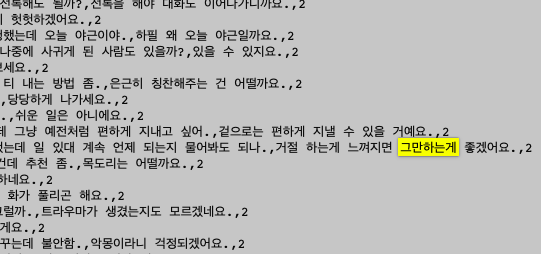


이제 그만하시는게 좋아요. 가 원시 데이터에서는 찾아아지지 않음